#Loading and preparing dataset.

In [17]:
from scipy.io.arff import loadarff
import pandas as pd
import sklearn
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np


data = loadarff('column_diagnosis.arff')
df = pd.DataFrame(data[0])
df['class'] = df['class'].str.decode('utf-8')

X = df.drop('class', axis=1)
y = df['class']

#1. Applying k-means for different k values, and assessing silhouette and purity of the produced solutions.

In [18]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.cluster import contingency_matrix


# Step 1: Normalize the Data
scaler = MinMaxScaler()
normalized_X = scaler.fit_transform(X)

# Step 2: Apply K-Means Clustering
k_values = [2, 3, 4, 5]
random_state = 0  # Set random_state for reproducibility

results = []

for k in k_values:
    # Apply k-means clustering
    kmeans = KMeans(n_clusters=k, random_state=random_state)
    cluster_labels = kmeans.fit_predict(normalized_X)

    if (k == 3):
      cluster_labels_k3 = kmeans.fit_predict(normalized_X)

    # Calculate silhouette score
    silhouette_avg = silhouette_score(normalized_X, cluster_labels)

    # Calculate contingency matrix for purity
    contingency_mat = contingency_matrix(y, cluster_labels)
    purity = np.sum(np.amax(contingency_mat, axis=0)) / np.sum(contingency_mat)

    results.append((k, silhouette_avg, purity))

# Print the results
for k, silhouette, purity in results:
    print(f'K={k}, Silhouette Score: {silhouette}, Purity: {purity}')

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


K=2, Silhouette Score: 0.36081773371884557, Purity: 0.6290322580645161
K=3, Silhouette Score: 0.29579055730002257, Purity: 0.667741935483871
K=4, Silhouette Score: 0.2686566721650703, Purity: 0.6612903225806451
K=5, Silhouette Score: 0.24328260038805272, Purity: 0.6741935483870968


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


#2. Identify the variability explained by the top two principal components.


In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(normalized_X)

explained_variance_ratio = pca.explained_variance_ratio_

print(f"Explained Variance Ratio (Top 2 components): {explained_variance_ratio[0]+explained_variance_ratio[1]}")

Explained Variance Ratio (Top 2 components): 0.7713739743435398


#2.ii) For each one of these two components, sorting the input variables by relevance by inspecting the absolute weights of the linear projection.

In [20]:
abs_weights = np.abs(pca.components_)

sorted_indices_1 = np.argsort(abs_weights[0])[::-1]

sorted_indices_2 = np.argsort(abs_weights[1])[::-1]

variable_names = X.columns

top_variables_component_1 = variable_names[sorted_indices_1]
top_variables_component_2 = variable_names[sorted_indices_2]


print(f"Top variables for Component 1: {top_variables_component_1.tolist()}")
print(f"Top variables for Component 2: {top_variables_component_2.tolist()}")

Top variables for Component 1: ['pelvic_incidence', 'lumbar_lordosis_angle', 'pelvic_tilt', 'sacral_slope', 'degree_spondylolisthesis', 'pelvic_radius']
Top variables for Component 2: ['pelvic_tilt', 'pelvic_radius', 'sacral_slope', 'pelvic_incidence', 'lumbar_lordosis_angle', 'degree_spondylolisthesis']


#3. Visualize side-by-side the data. Ground data VS predicted clusters with k-means(k=3).

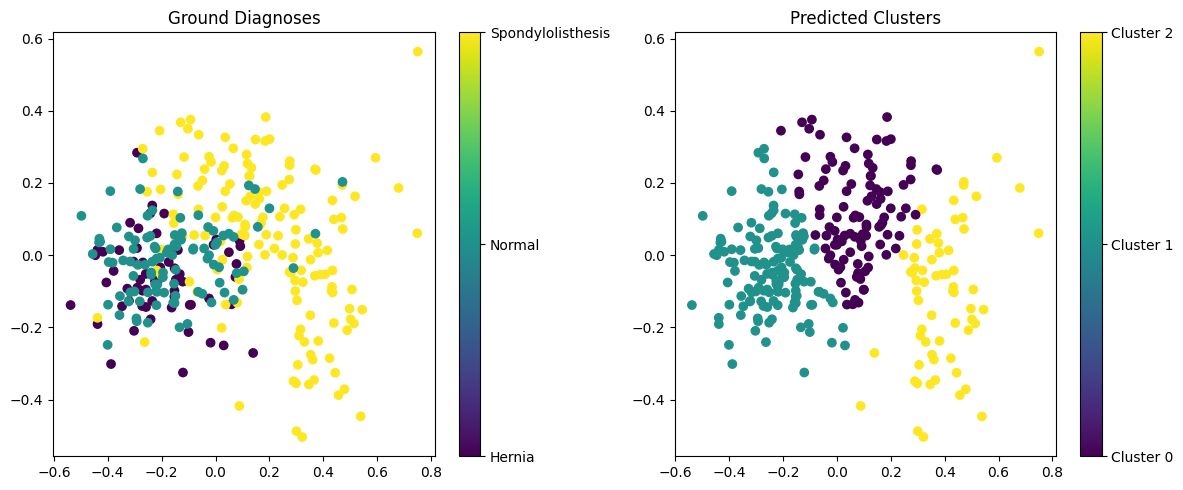

In [21]:
from sklearn.preprocessing import LabelEncoder

pca = PCA(n_components=2)
projected_data = pca.fit_transform(normalized_X)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

pca = PCA(n_components=2)
projected_data = pca.fit_transform(normalized_X)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

scatter1 = axs[0].scatter(projected_data[:, 0], projected_data[:, 1], c=y_encoded, cmap='viridis')
cbar1 = plt.colorbar(scatter1, ax=axs[0], ticks=range(len(label_encoder.classes_)))
cbar1.set_ticklabels(label_encoder.classes_)
axs[0].set_title('Ground Diagnoses')

scatter2 = axs[1].scatter(projected_data[:, 0], projected_data[:, 1], c=cluster_labels_k3, cmap='viridis')
cbar2 = plt.colorbar(scatter2, ax=axs[1], ticks=range(3))
cbar2.set_ticklabels(['Cluster 0', 'Cluster 1', 'Cluster 2'])
axs[1].set_title('Predicted Clusters')

plt.tight_layout()
plt.show()

#4. Considering the results from previous questions, identifying two ways on how clustering can be used to characterize the population of ill and healthy individuals.

Clustering can be used to characterize the population of ill and healthy individuals in two ways:


*   Subgroup Identification: Utilizing clustering techniques allows for the discernment of distinct subgroups within both the ill and healthy populations, based on shared characteristics. This process aids in the pinpointing of features most strongly correlated with the presence of the illness.

*    Risk Evaluation: Clustering can additionally serve as a tool for evaluating the likelihood of developing an illness. For instance, an individual situated within a cluster predominantly comprising ill individuals might be at a higher risk of contracting the illness compared to someone located within a cluster with a lower prevalence of ill individuals.

As we observe the visualization of our predicted clusters alongside the ground data, it becomes evident that our model encounters challenges in accurately determining whether a person is ill or not. However, as demonstrated in the first question, increasing the number of clusters leads to higher purity. This implies that within a given cluster, there is a greater likelihood of a person sharing the same diagnosis as the majority of that cluster's population. By augmenting the cluster count, we can identify clusters with high purity, facilitating the prediction of a person's diagnosis with greater certainty. It's worth noting that an excessive increase in cluster count may lead our model to overfit the dataset. This could result in the formation of clusters based on a limited number of data points, potentially hindering accurate diagnosis predictions.

